# ξ(r) and C(ℓ) examples

- Compute ξ(r) from emulator P(k) output.
- Compute C(ℓ) with the Limber API.
- Show curvature and source-redshift-distribution examples.

## ξ(r) from P(k)

- Linear and non-linear ξ(r) are computed through the public API.
- Internally this uses the P(k) emulator output.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dark_emulator2 import DarkEmulator2 as dq2

In [2]:
emu = dq2()
p = emu.param.get_fid_param()

lin_r, lin_xi = emu.get_lin_xi(p)
r, xi = emu.get_xi(p)

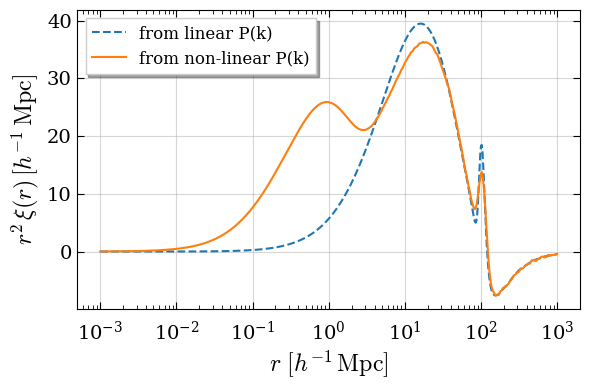

In [3]:
fig = plt.figure(figsize=(6, 4))
plt.plot(lin_r, lin_xi*lin_r**2, "--", label="from linear P(k)")
plt.plot(r, xi*r**2, "-", label="from non-linear P(k)")
plt.legend(fontsize="large")
plt.xscale("log")
plt.xlabel(r"$r \,\, [h^{-1}\, \mathrm{Mpc}]$", fontsize="xx-large")
plt.ylabel(r"$r^2 \, \xi(r) \, [h^{-1}\, \mathrm{Mpc}]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

## C(ℓ) from P(k)

- Linear and non-linear C(ℓ) are computed with Limber's approximation.
- The same API accepts custom redshift grids and source distributions.

In [4]:
emu = dq2()
p = emu.param.get_fid_param()

lin_l, lin_cl = emu.get_lin_cl_limber(p)
l, cl = emu.get_cl_limber(p)

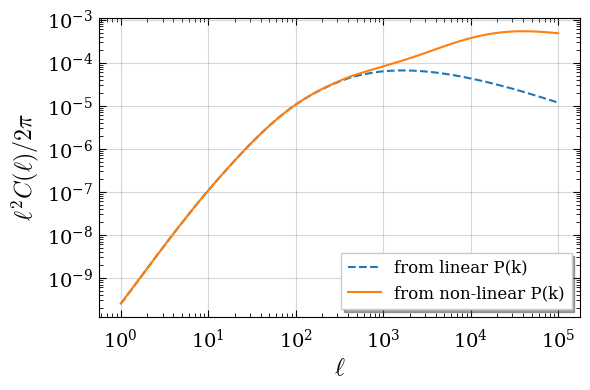

In [5]:
fig = plt.figure(figsize=(6, 4))
plt.plot(lin_l, (lin_l)**2 * lin_cl/(2.0*np.pi), "--", label="from linear P(k)")
plt.plot(l, (l)**2 * cl/(2.0*np.pi), "-", label="from non-linear P(k)")
plt.legend(fontsize="large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\ell$", fontsize="xx-large")
plt.ylabel(r"$\ell^2 C(\ell) / 2\pi$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

## Curvature example for C(ℓ)

- Vary Omega_k around the fiducial cosmology.
- Recompute dependent parameters with set_param().

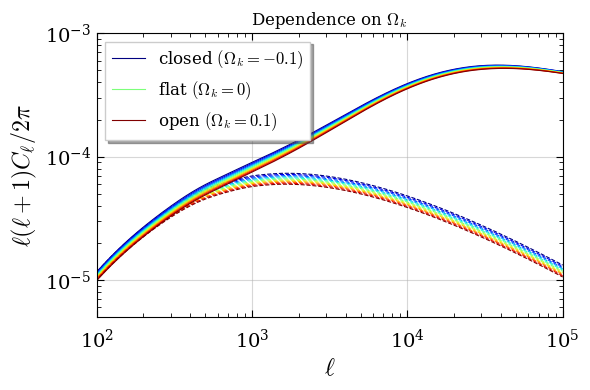

In [6]:
import matplotlib.cm as cm

emu = dq2()

Ok_list = np.linspace(-0.1,0.1, 11)
colors = cm.jet(np.linspace(0, 1, len(Ok_list)))

plt.figure(figsize=(6, 4))

for i, (ok, color) in enumerate(zip(Ok_list, colors)):
    p = emu.param.get_fid_param()
    p["Omega_k"] = ok

    emu.param.clear_As(p)
    emu.param.clear_lnAs(p)
    emu.param.clear_omega_cdm(p)
    emu.param.clear_Omega_de(p)

    p = emu.param.set_param(p)
    l, cl = emu.get_cl_limber(p)
    lin_l, lin_cl = emu.get_lin_cl_limber(p)

    if i == 0:
        label = r"closed $(\Omega_k=-0.1)$".format(ok)
    elif i == len(Ok_list)//2:
        label = r"flat $(\Omega_k=0)$".format(ok)
    elif i == len(Ok_list)-1:
        label = r"open $(\Omega_k=0.1)$".format(ok)
    else:
        label = None

    plt.loglog(l, l*(l+1)*cl/(2*np.pi), color=color, lw=0.8, label=label)
    plt.loglog(l, l*(l+1)*lin_cl/(2*np.pi),"--" , lw=0.8, color=color)

plt.xlim(100,100000)
plt.ylim(5e-6,1e-3)

plt.legend(fontsize="large")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.title(r"Dependence on $\Omega_k$")
plt.grid(True)
plt.tight_layout()
plt.show()

## Source redshift distributions

- Build normalized n_s(z) curves.
- Compare their impact on C(ℓ).

Smail 1.0
Gaussian 0.9999999999999998
Top-hat 1.0
Power-law 0.9999999999999999


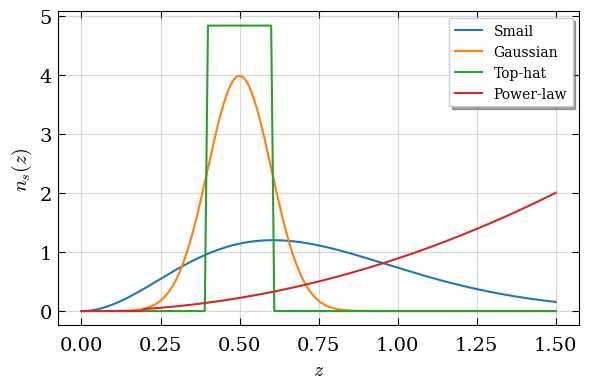

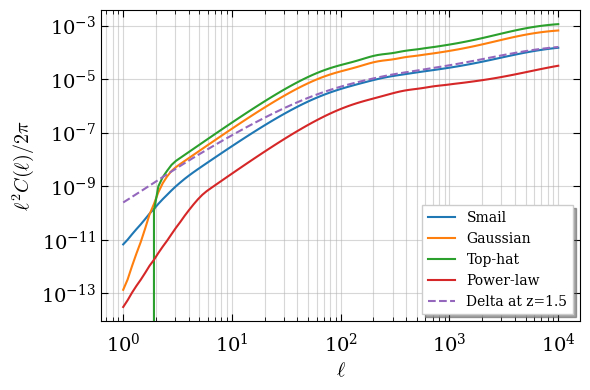

In [7]:

from dark_emulator2.derived import redshift_dist_func as nsz
emu = dq2()
p = emu.param.get_fid_param()
zlist = np.linspace(0, 1.5, 151)
llist = np.logspace(0, 4, 100)
distributions = {
    "Smail": nsz.smail_nsz(zlist, z0=0.5),
    "Gaussian": nsz.gaussian_nsz(zlist, mu=0.5, sigma=0.1),
    "Top-hat": nsz.tophat_nsz(zlist, zmin=0.4, zmax=0.6),
    "Power-law": nsz.power_law_nsz(zlist, z0=0.2, alpha=2.0)
}
from scipy.integrate import simpson

for label, n_s in distributions.items():
    print(label, simpson(n_s, x=zlist))
plt.figure(figsize=(6, 4))
for label, n_s in distributions.items():
    plt.plot(zlist, n_s, label=label)
plt.xlabel(r"$z$", fontsize="x-large")
plt.ylabel(r"$n_s(z)$", fontsize="x-large")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
for label, n_s in distributions.items():
    l, cl = emu.get_cl_limber(p, zlist=zlist, llist=llist, src_dist=n_s)
    plt.plot(l, l**2 * cl / (2*np.pi), label=label)
l, cl = emu.get_cl_limber(p, zlist=zlist, llist=llist, src_dist=None)
plt.plot(l, l**2 * cl / (2*np.pi), "--", label="Delta at z=1.5")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\ell$", fontsize="x-large")
plt.ylabel(r"$\ell^2 C(\ell) / 2\pi$", fontsize="x-large")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()
